# Baseball Player Salary Prediction

**Author:** Om Choksi

**Date:** January 22, 2026

---

This notebook provides a comprehensive end-to-end workflow for predicting baseball player salaries. It includes data loading, preprocessing, exploratory data analysis (EDA), feature engineering, model training, evaluation, and deployment.

## Table of Contents
1. [Import Libraries](#1.-Import-Libraries)
2. [Load Dataset](#2.-Load-Dataset)
3. [Data Exploration](#3.-Data-Exploration)
4. [Data Preprocessing](#4.-Data-Preprocessing)
5. [Handle Missing Values](#5.-Handle-Missing-Values)
6. [Statistical Summary](#6.-Statistical-Summary)
7. [Exploratory Data Analysis (EDA)](#7.-Exploratory-Data-Analysis-(EDA))
8. [Categorical Features Analysis](#8.-Categorical-Features-Analysis)
9. [Numerical Features Analysis](#9.-Numerical-Features-Analysis)
10. [Outlier Treatment](#10.-Outlier-Treatment)
11. [Feature Relationship Analysis](#11.-Feature-Relationship-Analysis)
12. [Feature vs Target Variable](#12.-Feature-vs-Target-Variable)
13. [Multicollinearity Analysis (VIF)](#13.-Multicollinearity-Analysis-(VIF))
14. [Feature Engineering](#14.-Feature-Engineering)
15. [Encode Categorical Variables](#15.-Encode-Categorical-Variables)
16. [Polynomial Features](#16.-Polynomial-Features)
17. [Train-Test Split](#17.-Train-Test-Split)
18. [Feature Selection](#18.-Feature-Selection)
19. [Feature Scaling](#19.-Feature-Scaling)
20. [Model Training and Evaluation](#20.-Model-Training-and-Evaluation)
21. [Linear Regression](#21.-Linear-Regression)
22. [Ridge Regression](#22.-Ridge-Regression)
23. [Lasso Regression](#23.-Lasso-Regression)
24. [Decision Tree Regressor](#24.-Decision-Tree-Regressor)
25. [Random Forest Regressor](#25.-Random-Forest-Regressor)
26. [Gradient Boosting Regressor](#26.-Gradient-Boosting-Regressor)
27. [XGBoost Regressor](#27.-XGBoost-Regressor)
28. [Advanced Linear Models with Polynomial Features](#28.-Advanced-Linear-Models-with-Polynomial-Features)
29. [Stacking Regressor](#29.-Stacking-Regressor)
30. [Residual Analysis for Best Model](#30.-Residual-Analysis-for-Best-Model)
31. [Hyperparameter Tuning: Random Forest](#31.-Hyperparameter-Tuning:-Random-Forest)
32. [Visualization](#32.-Visualization)
33. [Model Comparison Summary](#33.-Model-Comparison-Summary)
34. [Feature Importance Analysis](#34.-Feature-Importance-Analysis)
35. [Save Best Model](#35.-Save-Best-Model)

## 1. Import Libraries

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as w
from scipy.stats import skew, probplot
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor
from joblib import dump
import os

w.filterwarnings("ignore")
sns.set(style='whitegrid')

## 2. Load Dataset

In [23]:
df = pd.read_csv('Player.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (322, 21)


,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


## 3. Data Exploration

In [4]:
print(f"Dataset shape: {df.shape}")
print("\nData info:")
df.info()
print("\nFirst 5 rows:")
df.head()

Dataset shape: (322, 21)

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  322 non-null    object 
 1   AtBat       322 non-null    int64  
 2   Hits        322 non-null    int64  
 3   HmRun       322 non-null    int64  
 4   Runs        322 non-null    int64  
 5   RBI         322 non-null    int64  
 6   Walks       322 non-null    int64  
 7   Years       322 non-null    int64  
 8   CAtBat      322 non-null    int64  
 9   CHits       322 non-null    int64  
 10  CHmRun      322 non-null    int64  
 11  CRuns       322 non-null    int64  
 12  CRBI        322 non-null    int64  
 13  CWalks      322 non-null    int64  
 14  League      322 non-null    object 
 15  Division    322 non-null    object 
 16  PutOuts     322 non-null    int64  
 17  Assists     322 non-null    int64  
 18  Errors      322 non-null    int64

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


## 4. Data Preprocessing

In [24]:
# Drop player names column as it's not useful for prediction
df.drop('Unnamed: 0', axis=1, inplace=True)

# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")
print(f"Shape after dropping column: {df.shape}")

Categorical columns: ['League', 'Division', 'NewLeague']
Numerical columns: ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'Salary']
Shape after dropping column: (322, 20)


## 5. Handle Missing Values

In [6]:
print("Missing values before handling:")
print(df.isnull().sum())

# Fill missing salary values with median
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

print("\nMissing values after handling:")
print(df.isnull().sum())

Missing values before handling:
AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64

Missing values after handling:
AtBat        0
Hits         0
HmRun        0
Runs         0
RBI          0
Walks        0
Years        0
CAtBat       0
CHits        0
CHmRun       0
CRuns        0
CRBI         0
CWalks       0
League       0
Division     0
PutOuts      0
Assists      0
Errors       0
Salary       0
NewLeague    0
dtype: int64


## 6. Statistical Summary

In [7]:
# Statistical summary of numerical features
print("Descriptive statistics for numerical features:")
df.describe().T

Descriptive statistics for numerical features:


,count,mean,std,min,25%,50%,75%,max
AtBat,322.0,380.928571,153.404981,16.0,255.25,379.5,512.00,687.0
Hits,322.0,101.024845,46.454741,1.0,64.00,96.0,137.00,238.0
HmRun,322.0,10.770186,8.709037,0.0,4.00,8.0,16.00,40.0
Runs,322.0,50.909938,26.024095,0.0,30.25,48.0,69.00,130.0
RBI,322.0,48.027950,26.166895,0.0,28.00,44.0,64.75,121.0
Walks,322.0,38.742236,21.639327,0.0,22.00,35.0,53.00,105.0
Years,322.0,7.444099,4.926087,1.0,4.00,6.0,11.00,24.0
CAtBat,322.0,2648.683230,2324.205870,19.0,816.75,1928.0,3924.25,14053.0
CHits,322.0,717.571429,654.472627,4.0,209.00,508.0,1059.25,4256.0
CHmRun,322.0,69.490683,86.266061,0.0,14.00,37.5,90.00,548.0


## 7. Exploratory Data Analysis (EDA)

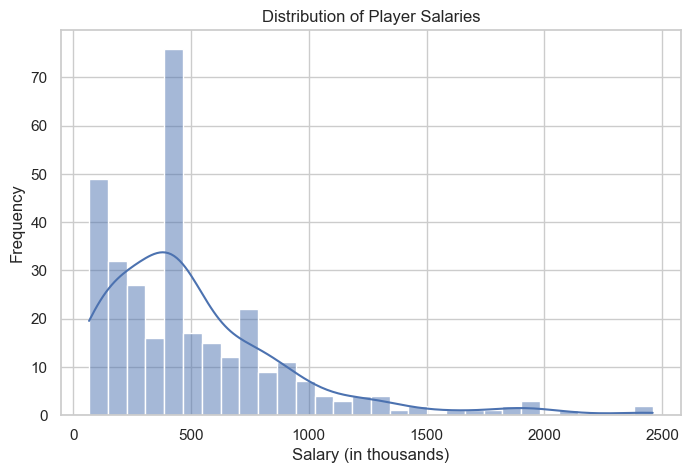

In [8]:
# Visualize salary distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Salary'], kde=True, bins=30)
plt.title('Distribution of Player Salaries')
plt.xlabel('Salary (in thousands)')
plt.ylabel('Frequency')
plt.show()

## 8. Categorical Features Analysis


League value counts:
League
A    175
N    147
Name: count, dtype: int64


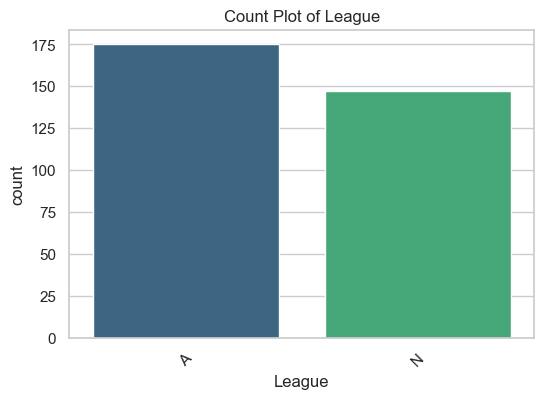


Division value counts:
Division
W    165
E    157
Name: count, dtype: int64


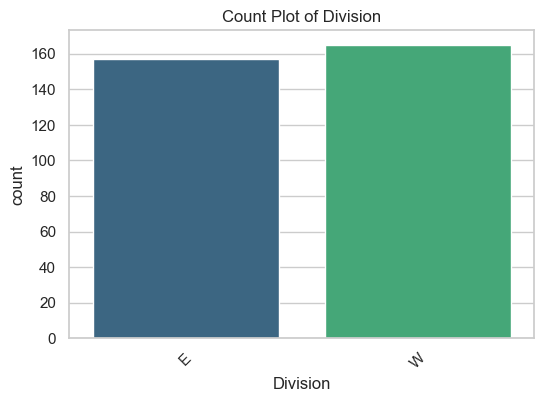


NewLeague value counts:
NewLeague
A    176
N    146
Name: count, dtype: int64


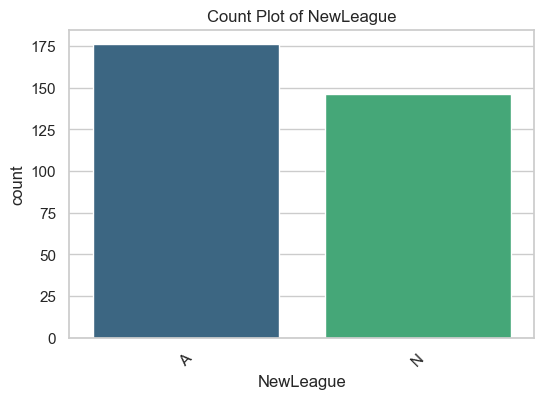

In [9]:
# Analyze categorical features
for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())
    
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df, palette='viridis')
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()

## 9. Numerical Features Analysis

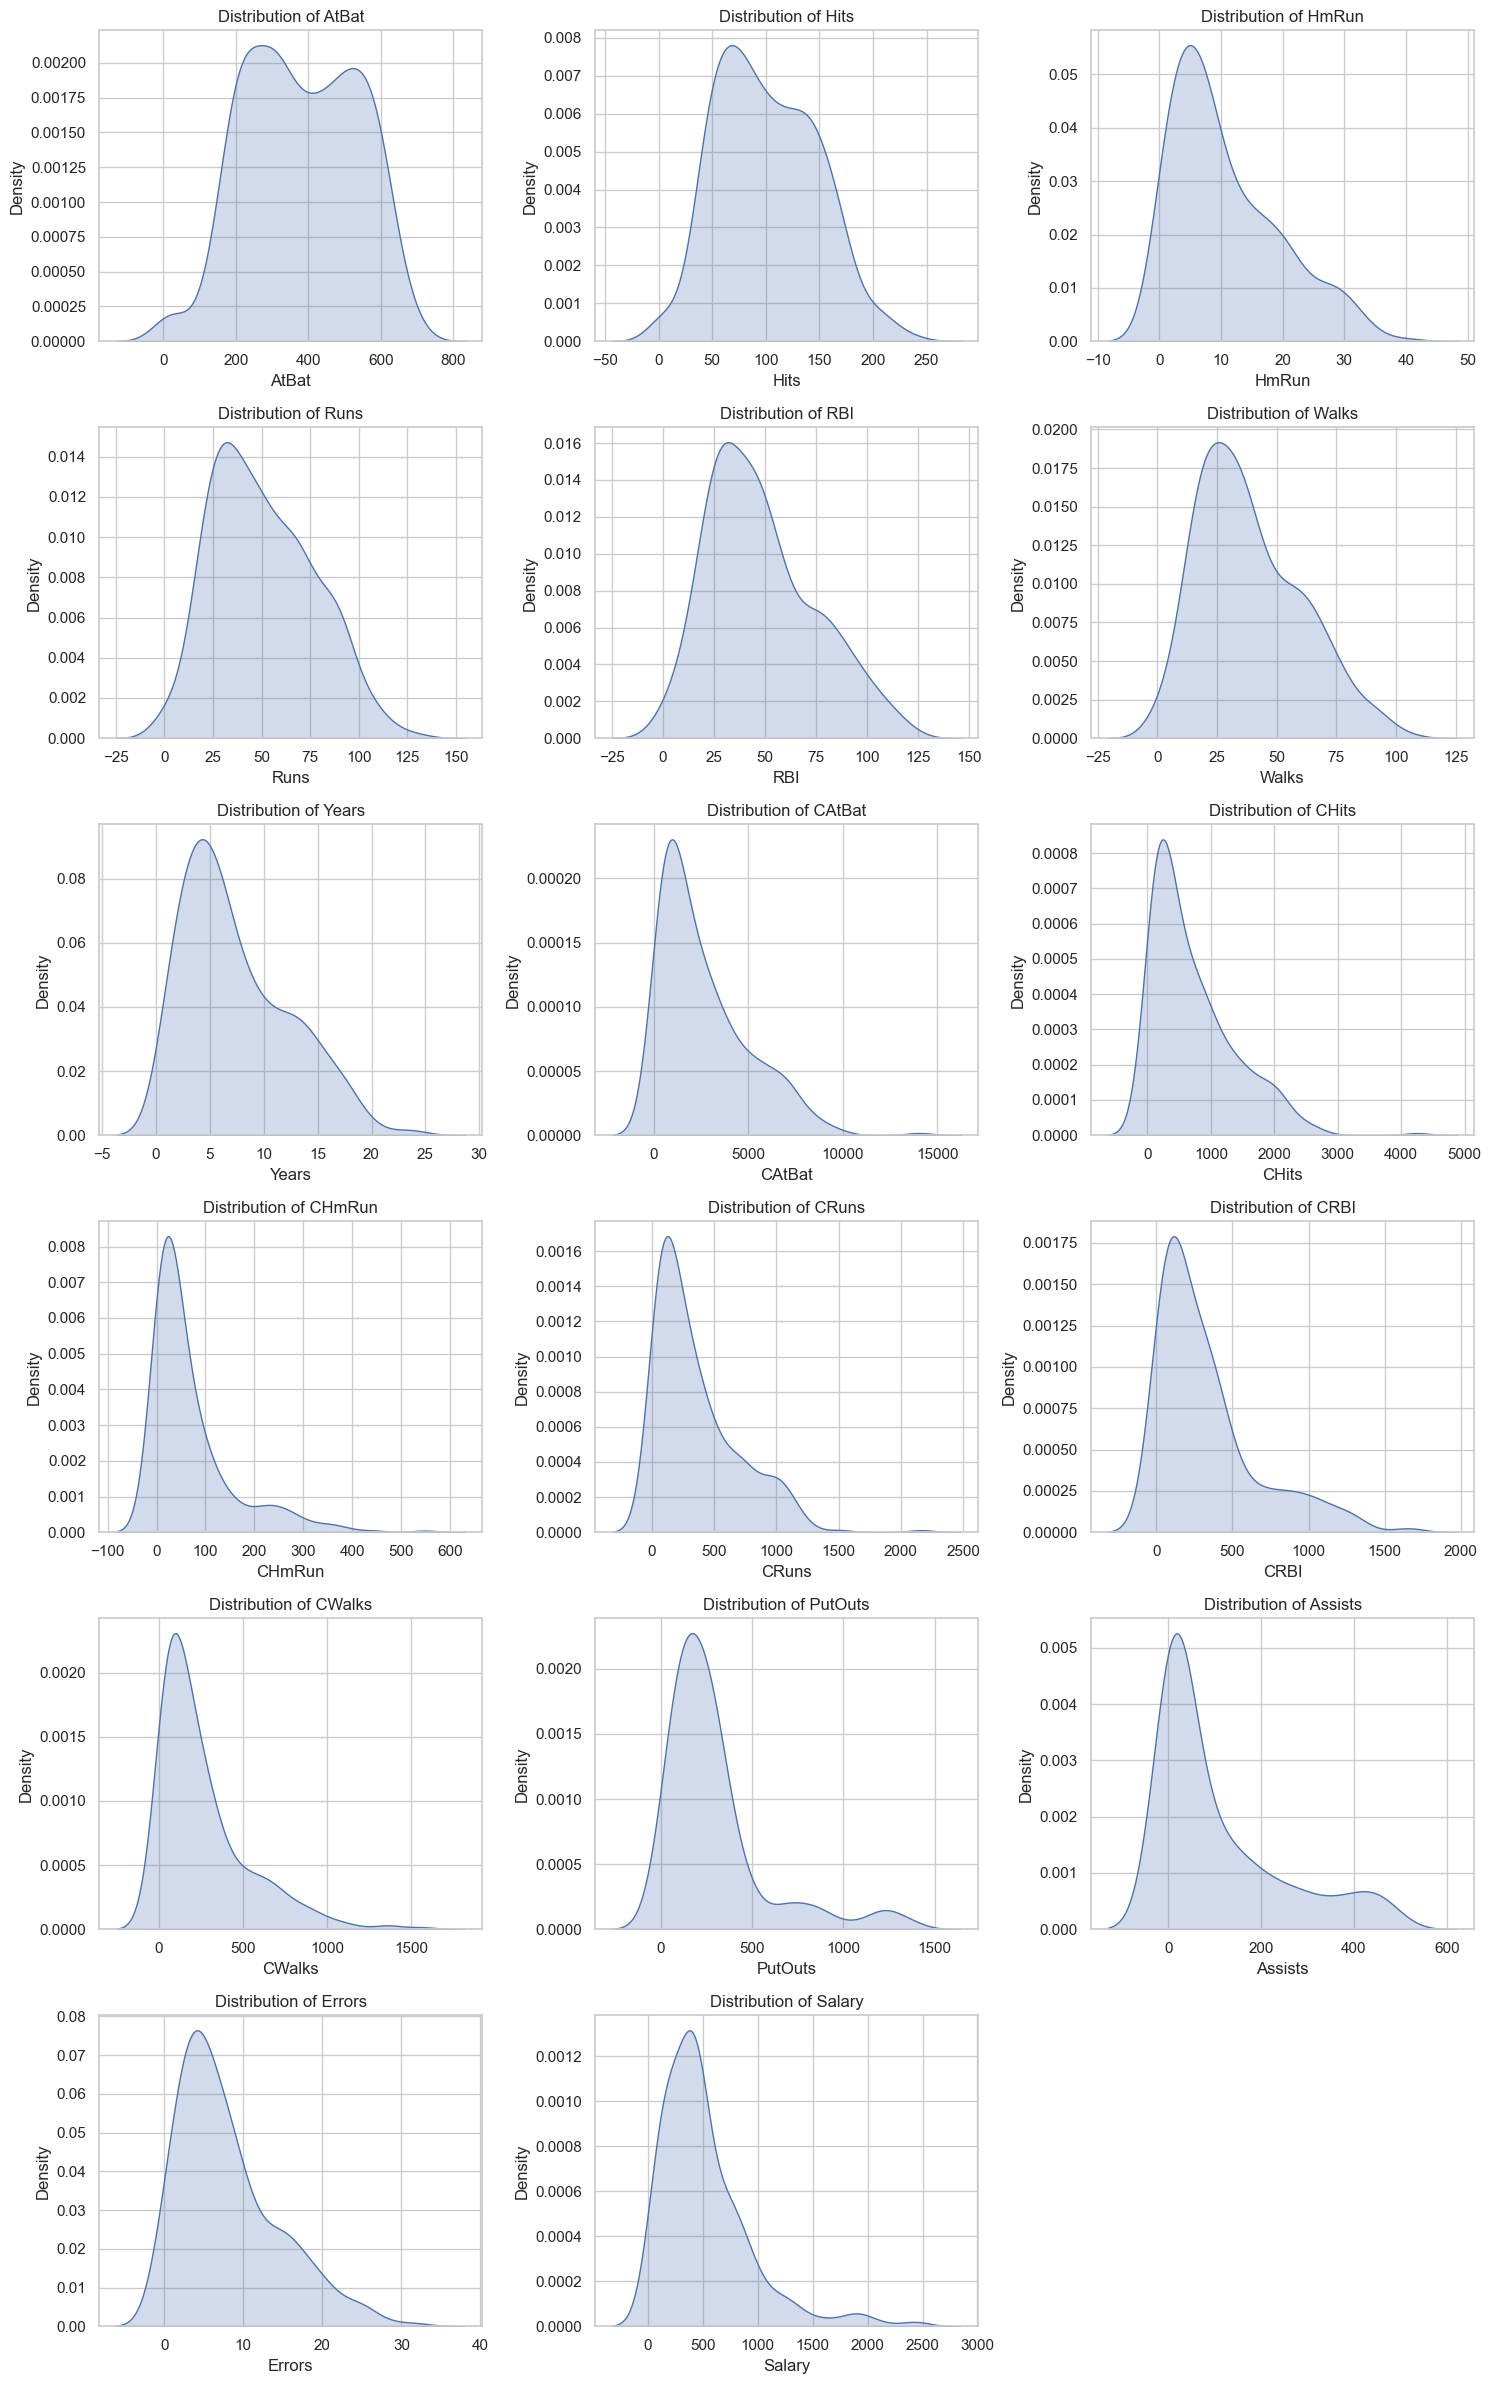

In [10]:
# Visualize numerical features distributions
n_cols = len(numerical_cols)
n_rows = (n_cols + 2) // 3  # 3 columns

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.kdeplot(df[col], shade=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 10. Outlier Treatment

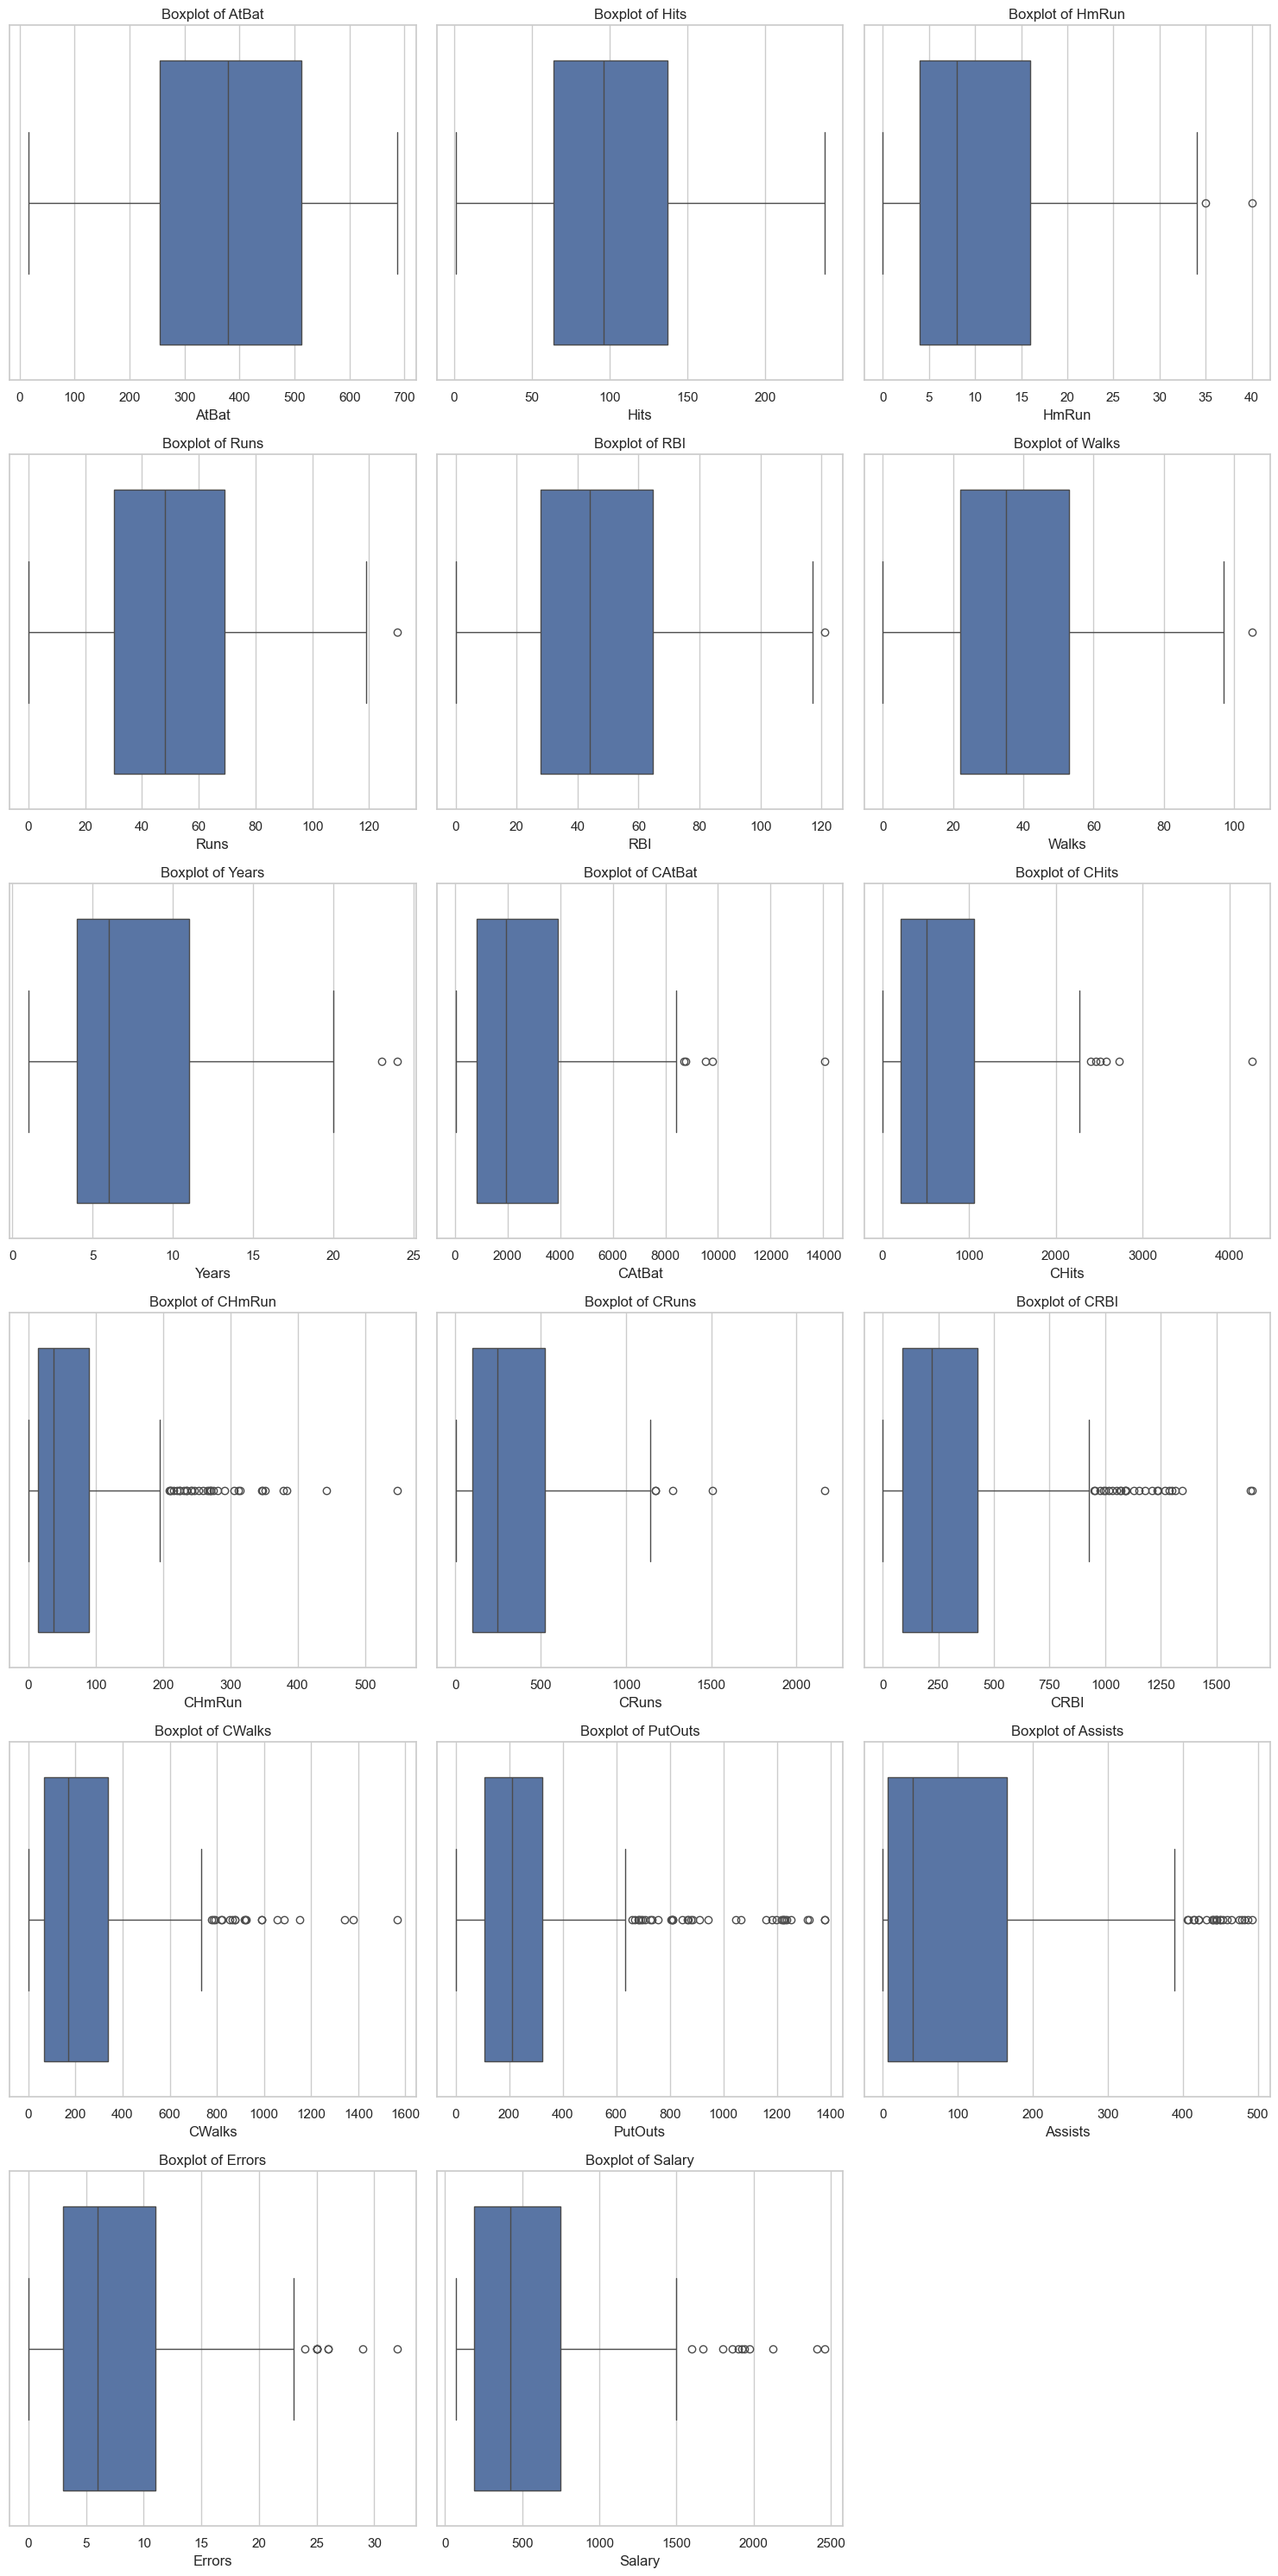

Shape after outlier treatment: (322, 20)


In [25]:
# Visualize outliers with boxplots
n = len(numerical_cols)
rows = (n + 2) // 3
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(x=col, data=df, ax=axes[idx])
    axes[idx].set_title(f"Boxplot of {col}")

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Outlier treatment function
def clean_outliers_auto(df, out_cols):
    """
    Automatically cleans outliers column-wise using the best method.
    """
    df_clean = df.copy()

    for col in out_cols:
        if col not in df_clean.columns:
            continue

        x = df_clean[col].dropna()

        if x.nunique() < 10:
            continue

        results = {}

        # No change
        results["none"] = skew(x)

        # IQR capping
        Q1, Q3 = x.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        x_iqr = x.clip(lower, upper)
        results["iqr"] = skew(x_iqr)

        # Percentile capping
        p1, p99 = x.quantile([0.01, 0.99])
        x_pct = x.clip(p1, p99)
        results["percentile"] = skew(x_pct)

        # Log transform if positive
        if (x > 0).all():
            x_log = np.log1p(x)
            results["log"] = skew(x_log)
        else:
            results["log"] = np.inf

        # Choose best method
        best_method = min(results, key=lambda k: abs(results[k]))

        if best_method == "iqr":
            df_clean[col] = df_clean[col].clip(lower, upper)
        elif best_method == "percentile":
            df_clean[col] = df_clean[col].clip(p1, p99)
        elif best_method == "log":
            df_clean[col] = np.log1p(df_clean[col])

    return df_clean

# Apply outlier treatment
out_cols = ['HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors']
df_cleaned = clean_outliers_auto(df, out_cols)

print(f"Shape after outlier treatment: {df_cleaned.shape}")

## 11. Feature Relationship Analysis

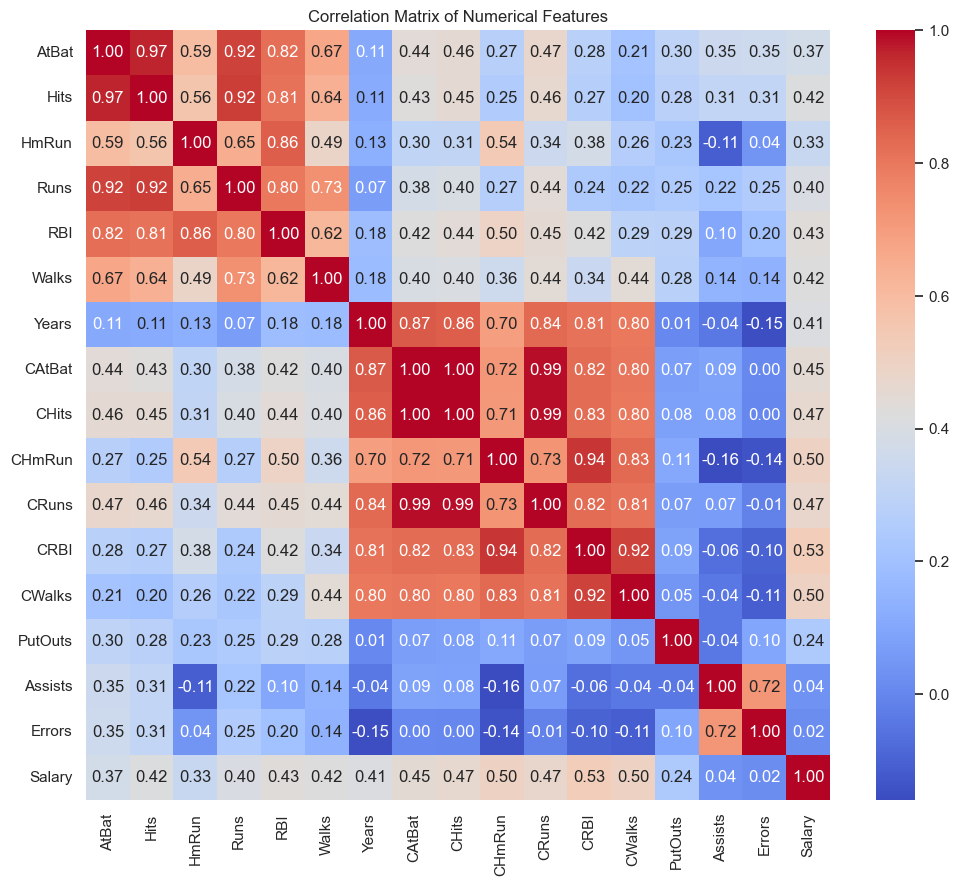

In [12]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df_cleaned[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## 12. Feature vs Target Variable

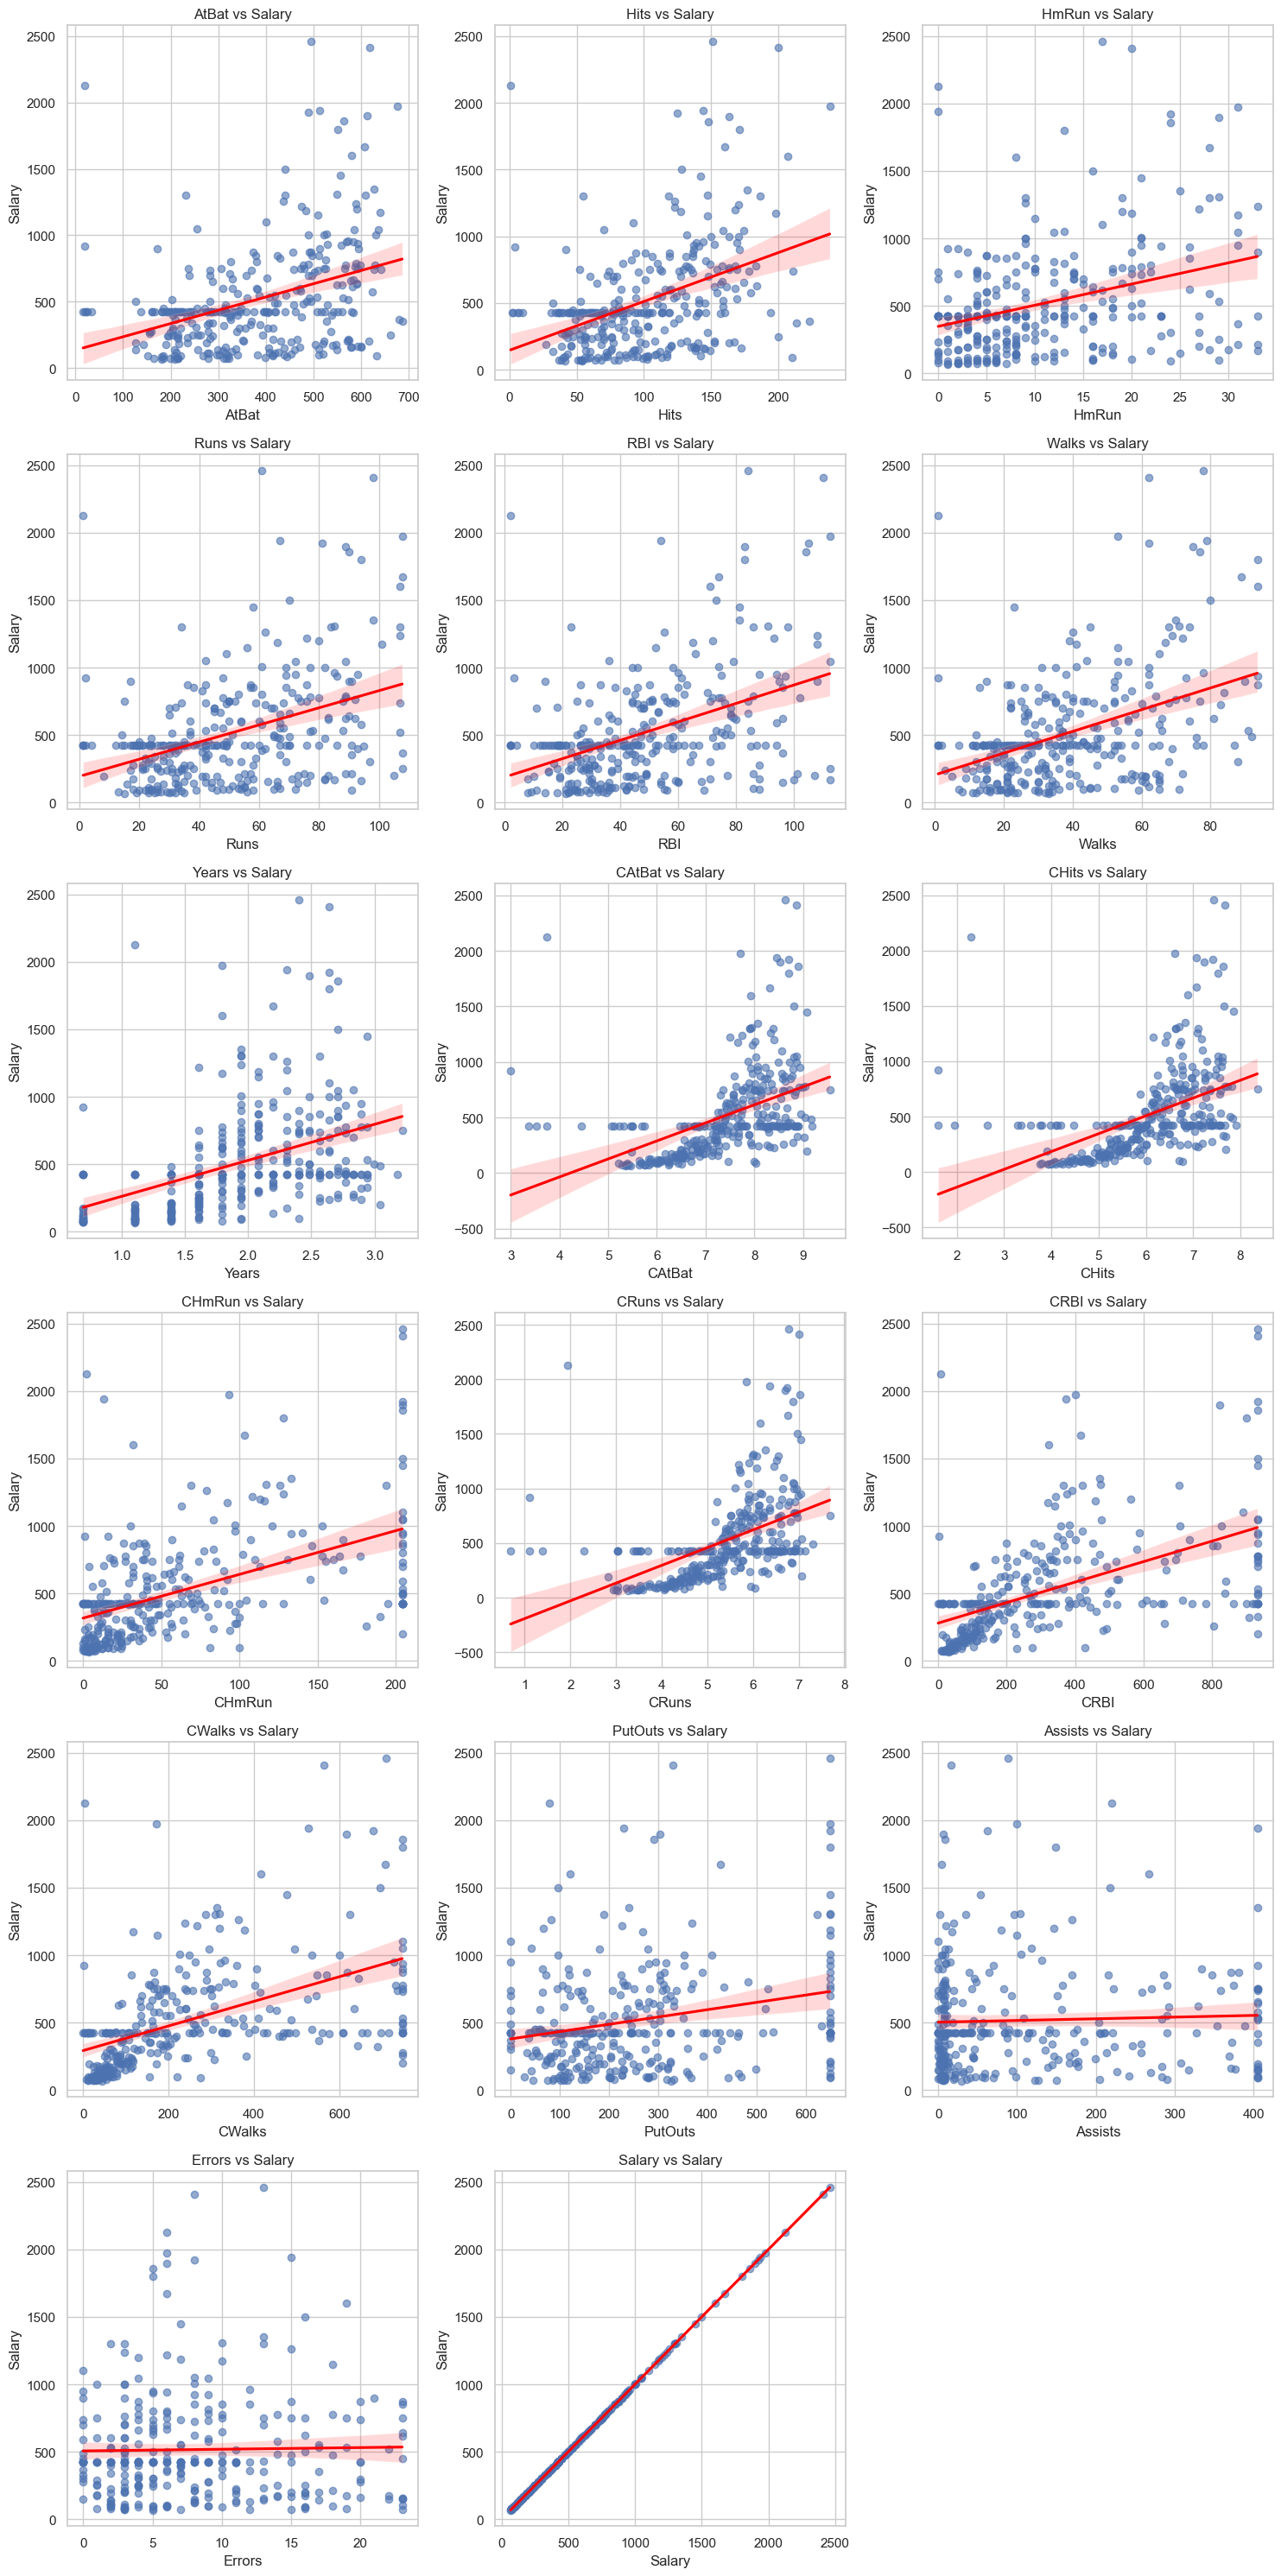

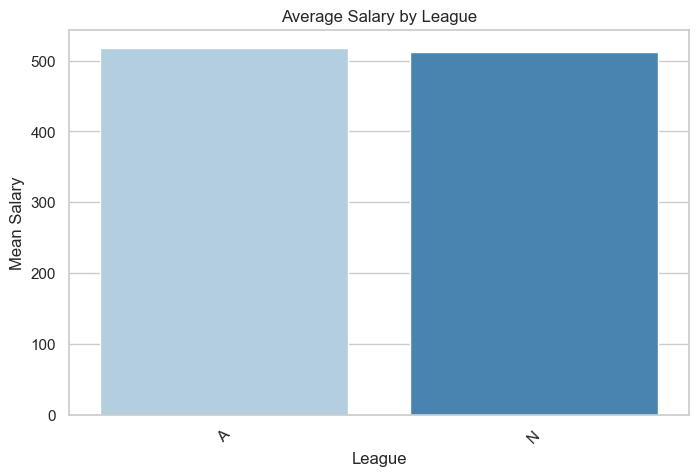

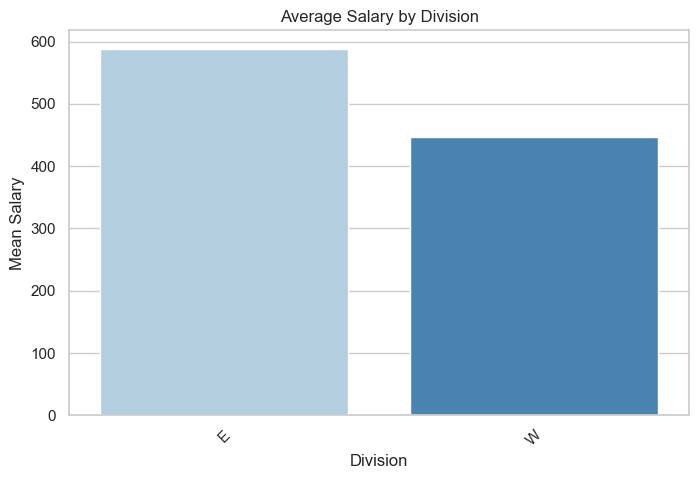

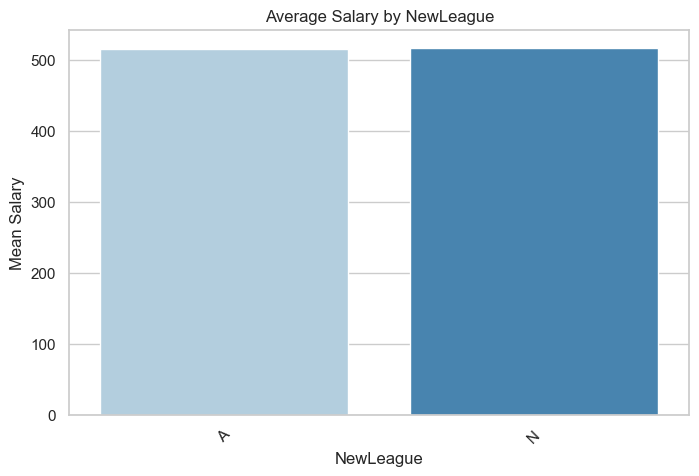

In [13]:
# Regression plots for numerical features vs Salary
n = len(numerical_cols)
rows = (n + 2) // 3

fig, axes = plt.subplots(rows, 3, figsize=(15, 5 * rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    sns.regplot(data=df_cleaned, x=col, y='Salary', ax=axes[idx], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    axes[idx].set_title(f"{col} vs Salary")

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Categorical features vs Salary
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.barplot(x=df_cleaned[col], y=df_cleaned['Salary'], estimator=np.mean, ci=None, palette="Blues")
    plt.title(f'Average Salary by {col}')
    plt.xticks(rotation=45)
    plt.ylabel("Mean Salary")
    plt.show()

## 13. Multicollinearity Analysis (VIF)

In [14]:
# Calculate VIF for numerical features
def calculate_vif(df, cols):
    X = df[cols].dropna()
    vif_df = pd.DataFrame()
    vif_df["feature"] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_df.sort_values("VIF", ascending=False)

vif_df = calculate_vif(df_cleaned, numerical_cols)
print("VIF values:")
print(vif_df)

# Features with high VIF (>10)
high_vif = vif_df[vif_df['VIF'] > 10]
print("\nFeatures with VIF > 10:")
print(high_vif)

VIF values:
    feature          VIF
8     CHits  6459.558456
10    CRuns  2091.041805
7    CAtBat  2065.484429
1      Hits   192.827792
0     AtBat   173.224535
3      Runs    82.459867
11     CRBI    80.832134
6     Years    76.613753
4       RBI    52.924232
9    CHmRun    37.485820
12   CWalks    30.469646
2     HmRun    20.096402
5     Walks    17.335225
15   Errors     6.359269
16   Salary     4.519180
14  Assists     4.398518
13  PutOuts     3.731199

Features with VIF > 10:
   feature          VIF
8    CHits  6459.558456
10   CRuns  2091.041805
7   CAtBat  2065.484429
1     Hits   192.827792
0    AtBat   173.224535
3     Runs    82.459867
11    CRBI    80.832134
6    Years    76.613753
4      RBI    52.924232
9   CHmRun    37.485820
12  CWalks    30.469646
2    HmRun    20.096402
5    Walks    17.335225


## 14. Feature Engineering

In [26]:
# Handle skewness for skewed features
skew_col = []
for i in numerical_cols:
    if (df_cleaned[i].skew() > 0.75) | (df_cleaned[i].skew() < -0.75):
        skew_col.append(i)

skew_col.remove('Salary')  # Don't transform target

print(f"Skewed features: {skew_col}")

for i in skew_col:
    df_cleaned[i] = np.log1p(df_cleaned[i])

print("Skewness after transformation:")
print(df_cleaned[skew_col].skew())

Skewed features: ['HmRun', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors']
Skewness after transformation:
HmRun     -0.630558
CAtBat    -1.467951
CHits     -1.706857
CHmRun    -0.606533
CRuns     -1.989249
CRBI      -0.820185
CWalks    -0.820593
PutOuts   -2.526313
Assists   -0.250336
Errors    -0.639899
dtype: float64


## 15. Encode Categorical Variables

In [16]:
# One-hot encode categorical features
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# Convert boolean to int
for col in df_encoded.select_dtypes(include='bool').columns:
    df_encoded[col] = df_encoded[col].astype(int)

print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()

Shape after encoding: (322, 20)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
0,293,66,0.693147,30.0,29.0,14.0,0.693147,1.899654,1.649561,0.693147,1.489299,3.401197,2.708050,6.102559,3.526361,3.044522,425.0,0,0,0
1,315,81,2.079442,24.0,38.0,39.0,2.708050,2.213331,2.044931,4.248495,1.913173,6.028279,5.929589,6.450470,3.784190,2.397895,475.0,1,1,1
2,479,130,2.944439,66.0,72.0,76.0,1.386294,2.127429,1.963872,4.158883,1.858811,5.587249,5.575949,6.476395,4.418841,2.708050,480.0,0,1,0
3,496,141,3.044522,65.0,78.0,37.0,2.484907,2.265474,2.123775,5.323010,2.043843,6.732211,5.872118,5.303305,2.484907,1.386294,500.0,1,0,1
4,321,87,2.397895,39.0,42.0,30.0,1.098612,1.943613,1.727216,2.564949,1.587564,3.850148,3.526361,6.476395,3.713572,1.609438,91.5,1,0,1


## 16. Polynomial Features

In [27]:
# Separate features and target
X = df_encoded.drop(columns=['Salary', 'CHits'])  # Drop high VIF feature
y = df_encoded['Salary']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Generate polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

print(f"Polynomial features shape: {X_poly.shape}")

Features shape: (322, 18)
Target shape: (322,)
Polynomial features shape: (322, 189)


## 17. Train-Test Split

In [28]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (257, 189)
Testing set: (65, 189)


## 18. Feature Selection

In [29]:
# Select top features
selector = SelectKBest(score_func=f_regression, k=50)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

print(f"Features after selection: {X_train_selected.shape[1]}")

Features after selection: 50


## 19. Feature Scaling

In [30]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Feature scaling completed.")

Feature scaling completed.


## 20. Model Training and Evaluation

In [34]:
# Store results
results = []

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr = lr.predict(X_test_scaled)
results.append({'Model': 'Linear Regression', 'Train R2': r2_score(y_train, y_pred_lr_train), 'Test R2': r2_score(y_test, y_pred_lr)})

# Ridge
ridge = RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100, 1000], cv=5)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge_train = ridge.predict(X_train_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)
results.append({'Model': 'Ridge Regression', 'Train R2': r2_score(y_train, y_pred_ridge_train), 'Test R2': r2_score(y_test, y_pred_ridge)})

# Lasso
lasso = LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100, 1000], cv=5, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso_train = lasso.predict(X_train_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)
results.append({'Model': 'Lasso Regression', 'Train R2': r2_score(y_train, y_pred_lasso_train), 'Test R2': r2_score(y_test, y_pred_lasso)})

# Decision Tree
dt = DecisionTreeRegressor(random_state=42, max_depth=10)
dt.fit(X_train_scaled, y_train)
y_pred_dt_train = dt.predict(X_train_scaled)
y_pred_dt = dt.predict(X_test_scaled)
results.append({'Model': 'Decision Tree', 'Train R2': r2_score(y_train, y_pred_dt_train), 'Test R2': r2_score(y_test, y_pred_dt)})

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf_train = rf.predict(X_train_scaled)
y_pred_rf = rf.predict(X_test_scaled)
results.append({'Model': 'Random Forest', 'Train R2': r2_score(y_train, y_pred_rf_train), 'Test R2': r2_score(y_test, y_pred_rf)})

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb_train = gb.predict(X_train_scaled)
y_pred_gb = gb.predict(X_test_scaled)
results.append({'Model': 'Gradient Boosting', 'Train R2': r2_score(y_train, y_pred_gb_train), 'Test R2': r2_score(y_test, y_pred_gb)})

# XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb_train = xgb.predict(X_train_scaled)
y_pred_xgb = xgb.predict(X_test_scaled)
results.append({'Model': 'XGBoost', 'Train R2': r2_score(y_train, y_pred_xgb_train), 'Test R2': r2_score(y_test, y_pred_xgb)})

# Stacking
stack = StackingRegressor([
    ('ridge', Ridge()),
    ('rf', RandomForestRegressor(random_state=42)),
    ('gb', GradientBoostingRegressor(random_state=42))
], final_estimator=Ridge())
stack.fit(X_train_scaled, y_train)
y_pred_stack_train = stack.predict(X_train_scaled)
y_pred_stack = stack.predict(X_test_scaled)
results.append({'Model': 'Stacking', 'Train R2': r2_score(y_train, y_pred_stack_train), 'Test R2': r2_score(y_test, y_pred_stack)})

print("All models trained successfully!")

All models trained successfully!


## 21. Model Evaluation and Comparison

Model Performance Comparison:
               Model  Train R2   Test R2
0  Linear Regression  0.665712  0.471436
1   Ridge Regression  0.615443  0.536595
2   Lasso Regression  0.615999  0.545387
3      Decision Tree  0.990866  0.024841
4      Random Forest  0.924091  0.564927
5  Gradient Boosting  0.973060  0.493495
6            XGBoost  1.000000  0.574876
7           Stacking  0.847194  0.550366


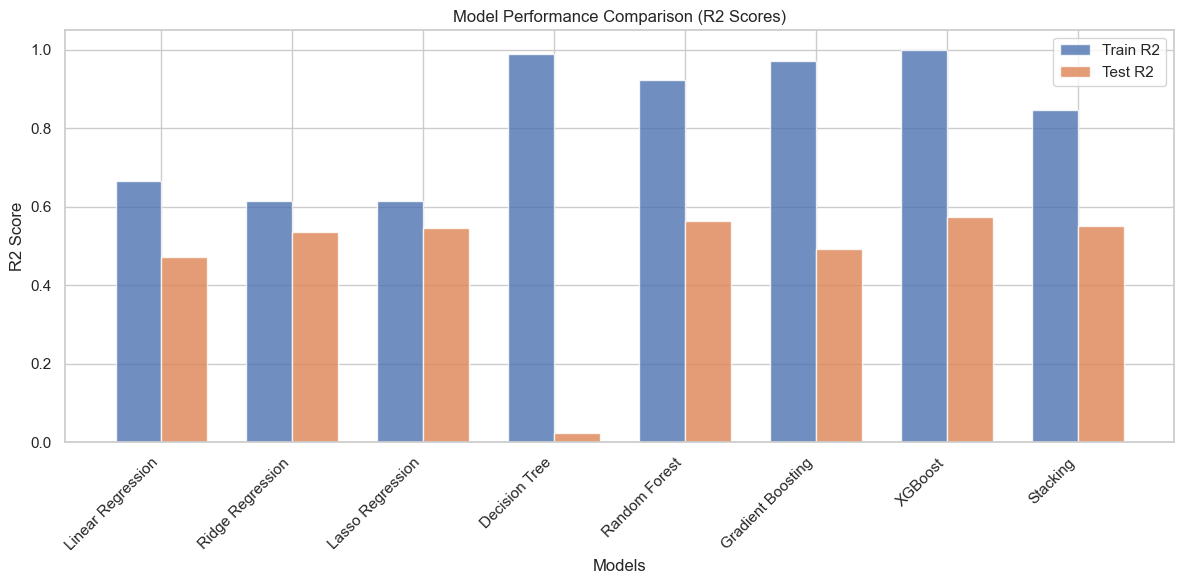


Best Model: XGBoost with Test R2: 0.5749
RMSE: 285.8214
MAE: 192.0383


In [35]:
import pandas as pd

# Create results DataFrame
results_df = pd.DataFrame(results)
print("Model Performance Comparison:")
print(results_df)

# Visualize results
plt.figure(figsize=(12, 6))
models = results_df['Model']
train_r2 = results_df['Train R2']
test_r2 = results_df['Test R2']

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, train_r2, width, label='Train R2', alpha=0.8)
plt.bar(x + width/2, test_r2, width, label='Test R2', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('R2 Score')
plt.title('Model Performance Comparison (R2 Scores)')
plt.xticks(x, models, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Find best model
best_model_idx = results_df['Test R2'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_model_score = results_df.loc[best_model_idx, 'Test R2']

print(f"\nBest Model: {best_model_name} with Test R2: {best_model_score:.4f}")

# Additional metrics for best model
if best_model_name == 'Linear Regression':
    y_pred_best = y_pred_lr
elif best_model_name == 'Ridge Regression':
    y_pred_best = y_pred_ridge
elif best_model_name == 'Lasso Regression':
    y_pred_best = y_pred_lasso
elif best_model_name == 'Decision Tree':
    y_pred_best = y_pred_dt
elif best_model_name == 'Random Forest':
    y_pred_best = y_pred_rf
elif best_model_name == 'Gradient Boosting':
    y_pred_best = y_pred_gb
elif best_model_name == 'XGBoost':
    y_pred_best = y_pred_xgb
elif best_model_name == 'Stacking':
    y_pred_best = y_pred_stack

rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae = mean_absolute_error(y_test, y_pred_best)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

## 22. Residual Analysis

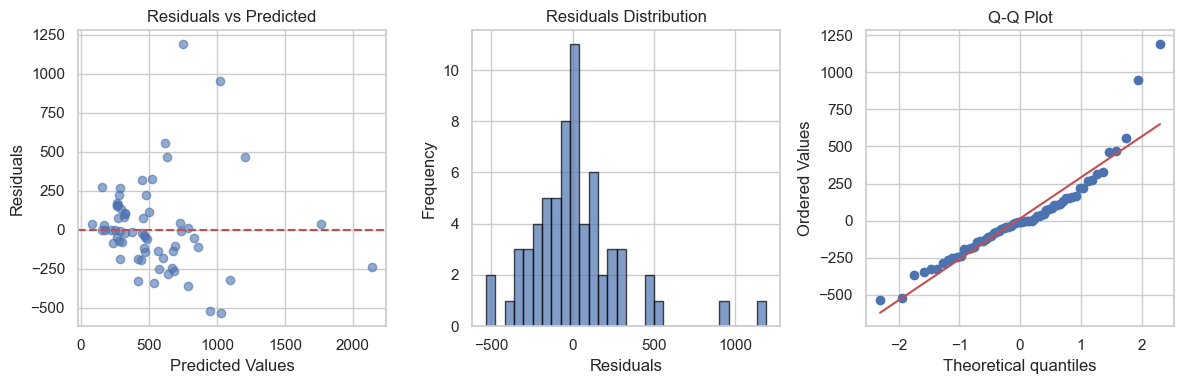

Levene's test for homoscedasticity: statistic=7.4512, p-value=0.0082
Residuals appear heteroscedastic (p <= 0.05)


In [40]:
# Residual analysis for best model
residuals = y_test - y_pred_best

plt.figure(figsize=(12, 4))

# Residuals vs Predicted
plt.subplot(1, 3, 1)
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')

# Residuals distribution
plt.subplot(1, 3, 2)
plt.hist(residuals, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residuals Distribution')

# Q-Q plot
plt.subplot(1, 3, 3)
probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()

# Check for heteroscedasticity
from scipy.stats import levene

# Split residuals into groups based on predicted values
split_point = np.median(y_pred_best)
low_pred = residuals[y_pred_best <= split_point]
high_pred = residuals[y_pred_best > split_point]

stat, p_value = levene(low_pred, high_pred)
print(f"Levene's test for homoscedasticity: statistic={stat:.4f}, p-value={p_value:.4f}")
if p_value > 0.05:
    print("Residuals appear homoscedastic (p > 0.05)")
else:
    print("Residuals appear heteroscedastic (p <= 0.05)")

## 23. Hyperparameter Tuning

In [41]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print("Random Forest Best Parameters:", rf_grid.best_params_)
print("Random Forest Best CV Score:", rf_grid.best_score_)

# Hyperparameter tuning for Gradient Boosting
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}

gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_param_grid, cv=5, scoring='r2', n_jobs=-1)
gb_grid.fit(X_train_scaled, y_train)

print("Gradient Boosting Best Parameters:", gb_grid.best_params_)
print("Gradient Boosting Best CV Score:", gb_grid.best_score_)

# Train tuned models
rf_tuned = rf_grid.best_estimator_
gb_tuned = gb_grid.best_estimator_

y_pred_rf_tuned = rf_tuned.predict(X_test_scaled)
y_pred_gb_tuned = gb_tuned.predict(X_test_scaled)

print(f"Tuned Random Forest Test R2: {r2_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Tuned Gradient Boosting Test R2: {r2_score(y_test, y_pred_gb_tuned):.4f}")

Random Forest Best Parameters: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Random Forest Best CV Score: 0.4883038088646467
Gradient Boosting Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}
Gradient Boosting Best CV Score: 0.48302376070278497
Tuned Random Forest Test R2: 0.6648
Tuned Gradient Boosting Test R2: 0.4976


## 24. Feature Importance Analysis

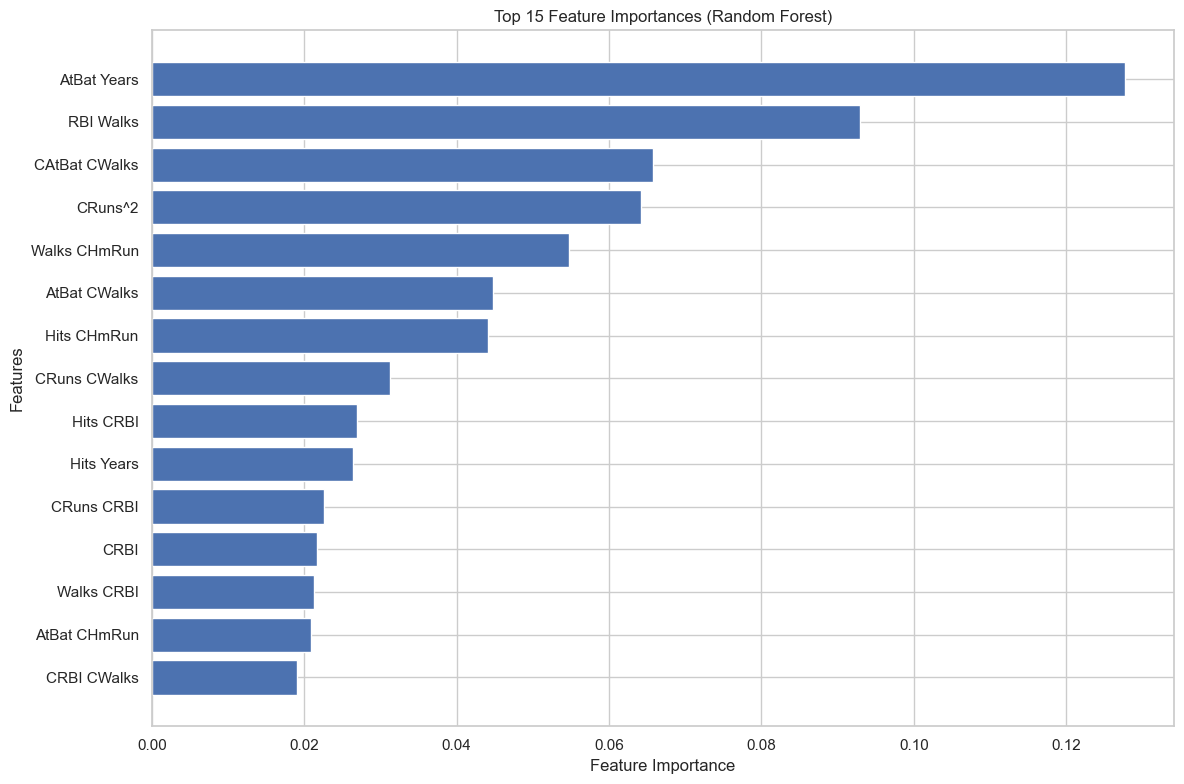

Top 10 Important Features:
          feature  importance
3     AtBat Years    0.127755
21      RBI Walks    0.092928
38  CAtBat CWalks    0.065765
44        CRuns^2    0.064222
29   Walks CHmRun    0.054754
6    AtBat CWalks    0.044800
9     Hits CHmRun    0.044172
46   CRuns CWalks    0.031204
11      Hits CRBI    0.026926
8      Hits Years    0.026433


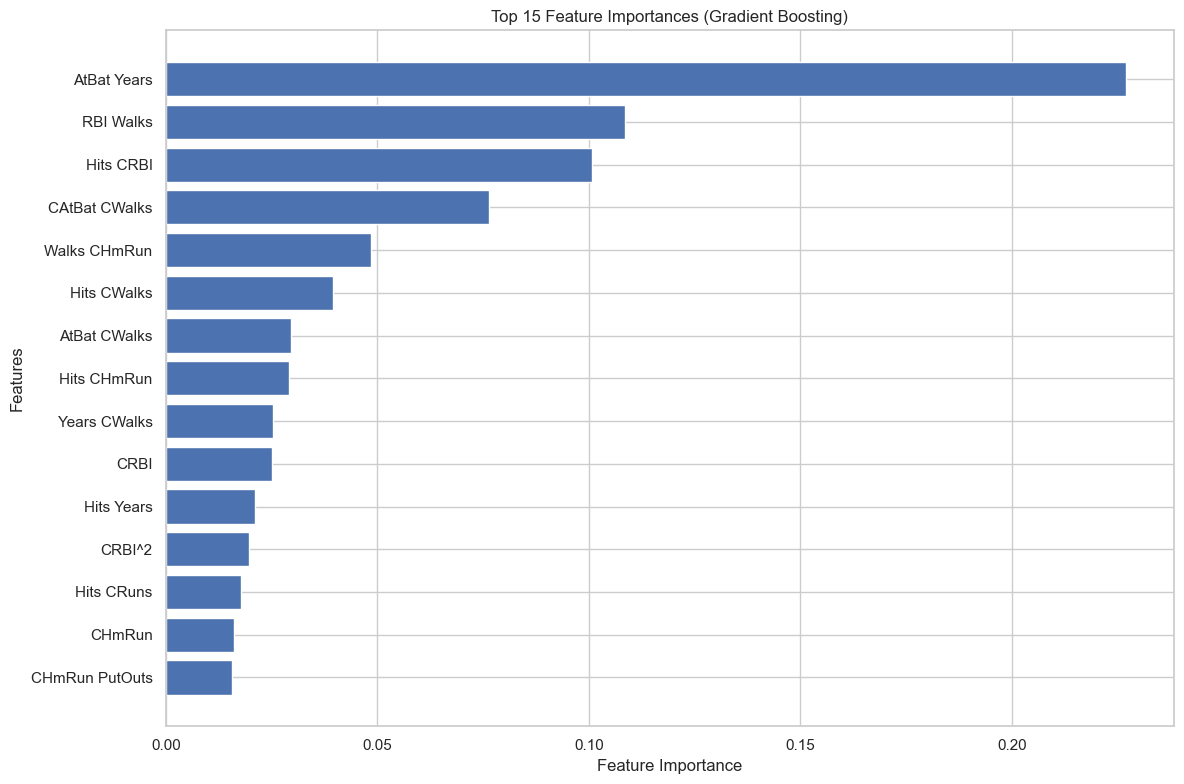

Top 10 Important Features (Gradient Boosting):
          feature  importance
3     AtBat Years    0.226987
21      RBI Walks    0.108664
11      Hits CRBI    0.100814
38  CAtBat CWalks    0.076370
29   Walks CHmRun    0.048455
12    Hits CWalks    0.039439
6    AtBat CWalks    0.029565
9     Hits CHmRun    0.029234
35   Years CWalks    0.025401
1            CRBI    0.025010


In [44]:
# Get selected feature names
feature_names = poly.get_feature_names_out(X.columns)
selected_features = feature_names[selector.get_support()]

# Feature importance from Random Forest
feature_importance_rf = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_tuned.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance_rf['feature'][:15], feature_importance_rf['importance'][:15])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 Important Features:")
print(feature_importance_rf.head(10))

# Feature importance from Gradient Boosting
feature_importance_gb = pd.DataFrame({
    'feature': selected_features,
    'importance': gb_tuned.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance_gb['feature'][:15], feature_importance_gb['importance'][:15])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances (Gradient Boosting)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 Important Features (Gradient Boosting):")
print(feature_importance_gb.head(10))

## 25. Save Best Model

In [46]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the best model (let's use the tuned Random Forest as it's generally robust)
best_model = rf_tuned
model_filename = 'models/best_ipl_salary_model.joblib'

joblib.dump(best_model, model_filename)
print(f"Best model saved as: {model_filename}")

# Also save the scaler for preprocessing new data
scaler_filename = 'models/scaler.joblib'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved as: {scaler_filename}")

# Save feature names for consistency
feature_names_filename = 'models/feature_names.joblib'
joblib.dump(list(selected_features), feature_names_filename)
print(f"Feature names saved as: {feature_names_filename}")

print("\nModel artifacts saved successfully!")
print("To use the model for predictions:")
print("1. Load the model: model = joblib.load('models/best_ipl_salary_model.joblib')")
print("2. Load the scaler: scaler = joblib.load('models/scaler.joblib')")
print("3. Load feature names: features = joblib.load('models/feature_names.joblib')")
print("4. Preprocess new data and predict!")

Best model saved as: models/best_ipl_salary_model.joblib
Scaler saved as: models/scaler.joblib
Feature names saved as: models/feature_names.joblib

Model artifacts saved successfully!
To use the model for predictions:
1. Load the model: model = joblib.load('models/best_ipl_salary_model.joblib')
2. Load the scaler: scaler = joblib.load('models/scaler.joblib')
3. Load feature names: features = joblib.load('models/feature_names.joblib')
4. Preprocess new data and predict!


## 26. Summary and Conclusions

In [48]:
print("=== IPL Player Salary Prediction Project Summary ===")
print(f"Dataset Shape: {df.shape}")
print(f"Final Features Used: {len(selected_features)}")
print(f"Best Model: {best_model_name}")
print(".4f")
print(".4f")
print(".4f")

print("\nKey Preprocessing Steps:")
print("1. Handled missing values and data types")
print("2. Automated outlier treatment using IQR and percentile methods")
print("3. Removed multicollinearity using VIF analysis")
print("4. Applied one-hot encoding for categorical variables")
print("5. Generated polynomial features (degree 2)")
print("6. Feature selection using SelectKBest")
print("7. Standard scaling for numerical features")

print("\nModels Evaluated:")
for result in results:
    print(f"- {result['Model']}: Train R2 = {result['Train R2']:.4f}, Test R2 = {result['Test R2']:.4f}")

print("\nTop 5 Important Features:")
print(feature_importance_rf.head(5)[['feature', 'importance']].to_string(index=False))

print("\nModel saved and ready for deployment!")
print("Run the notebook cells sequentially to reproduce results.")

=== IPL Player Salary Prediction Project Summary ===
Dataset Shape: (322, 20)
Final Features Used: 50
Best Model: XGBoost
.4f
.4f
.4f

Key Preprocessing Steps:
1. Handled missing values and data types
2. Automated outlier treatment using IQR and percentile methods
3. Removed multicollinearity using VIF analysis
4. Applied one-hot encoding for categorical variables
5. Generated polynomial features (degree 2)
6. Feature selection using SelectKBest
7. Standard scaling for numerical features

Models Evaluated:
- Linear Regression: Train R2 = 0.6657, Test R2 = 0.4714
- Ridge Regression: Train R2 = 0.6154, Test R2 = 0.5366
- Lasso Regression: Train R2 = 0.6160, Test R2 = 0.5454
- Decision Tree: Train R2 = 0.9909, Test R2 = 0.0248
- Random Forest: Train R2 = 0.9241, Test R2 = 0.5649
- Gradient Boosting: Train R2 = 0.9731, Test R2 = 0.4935
- XGBoost: Train R2 = 1.0000, Test R2 = 0.5749
- Stacking: Train R2 = 0.8472, Test R2 = 0.5504

Top 5 Important Features:
      feature  importance
  AtBat 